In [13]:
# Import neccessary packages
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.ticker as mticker
import seaborn as sns
import math

In [2]:
# Load Population data from VALESOR
# FIND FILE at
df_pop_BL = pd.read_excel(r"Input\8.xlsx", sheet_name='Population',  skiprows=[0])

# Economic regions
region_df = pd.read_excel("Output/region_allocation_check.xlsx")

In [3]:
pop_2020 = df_pop_BL[df_pop_BL['Year'].isin([2020])]
pop_2040 = df_pop_BL[df_pop_BL['Year'].isin([2040])]
pop_2015 = df_pop_BL[df_pop_BL['Year'].isin([2015])]


In [5]:
# Identifiera ålderskolumner och sortera dem numeriskt
age_cols = [col for col in pop_2020.columns if col not in ["Year", "Country", "Region", "Total", "Life expectancy"]]
age_cols = sorted(age_cols, key=lambda x: int(x))


In [6]:
pop_2020[age_cols] = pop_2020[age_cols].div(pop_2020["Total"], axis=0)
pop_2040[age_cols] = pop_2040[age_cols].div(pop_2040["Total"], axis=0)
pop_2015[age_cols] = pop_2015[age_cols].div(pop_2015["Total"], axis=0)

In [7]:
# Merge with regions

pop_2020_reg = pop_2020.merge(region_df, on="Country", how="inner").drop(columns=["Total", "Life expectancy"])
pop_2040_reg = pop_2040.merge(region_df, on="Country", how="inner").drop(columns=["Total", "Life expectancy"])
pop_2015_reg = pop_2015.merge(region_df, on="Country", how="inner").drop(columns=["Total", "Life expectancy"])

In [8]:
pop_2020_countries = pop_2020_reg[pop_2020_reg['Region'].isin(["UNECE Europe", "EECCA"])] 
to_plot_2020 = pop_2020_countries.drop_duplicates("Country", keep='first')
pop_2040_countries = pop_2040_reg[pop_2040_reg['Region'].isin(["UNECE Europe", "EECCA"])]
to_plot_2040 = pop_2040_countries.drop_duplicates("Country", keep='first')
pop_2015_countries = pop_2015_reg[pop_2015_reg['Region'].isin(["UNECE Europe", "EECCA"])]
to_plot_2015 = pop_2015_countries.drop_duplicates("Country", keep='first')

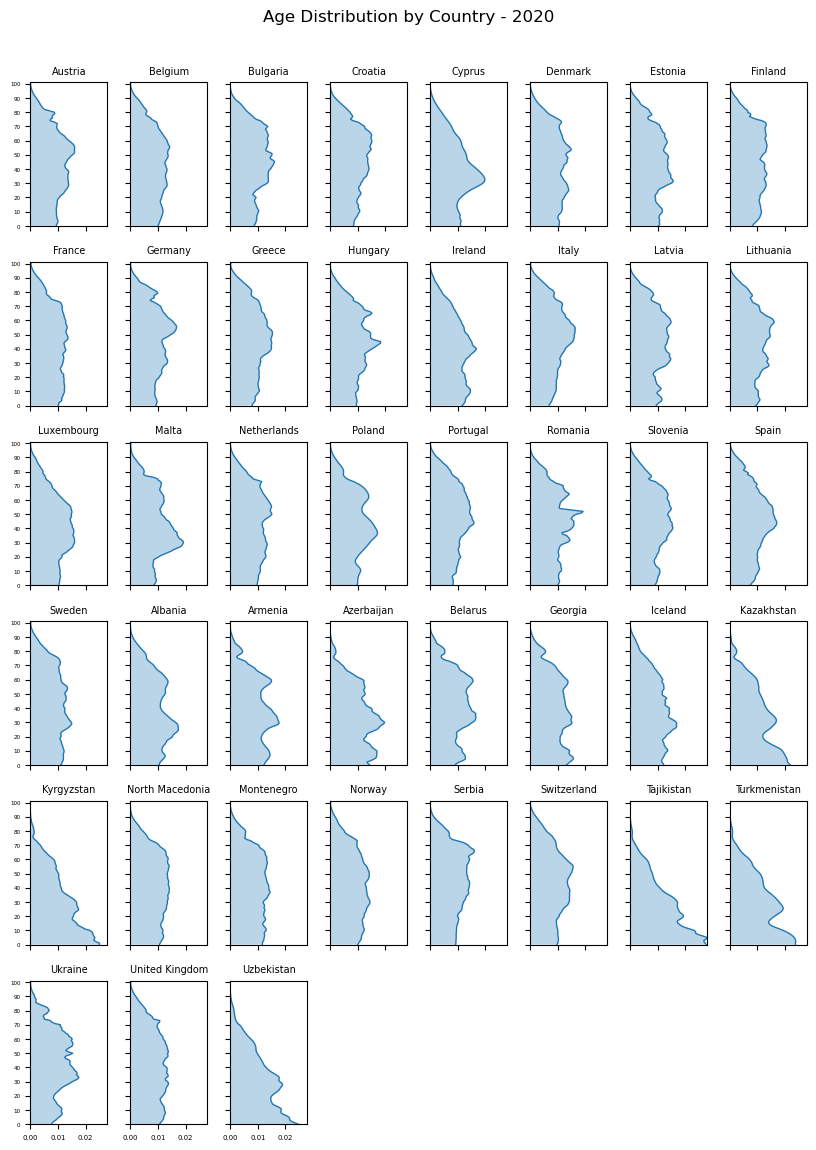

In [10]:
    # Kopiera data
plot_df = to_plot_2020.copy()

# Länder
countries = plot_df["Country"].tolist()
n_plots = len(countries)

# Grid
n_cols = 8
n_rows = math.ceil(n_plots / n_cols)

# A4
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(8.27, 11.69),
    sharex=True,
    sharey=True
)

axes = np.array(axes).reshape(-1)

# Gemensam x-skala
max_val = plot_df[age_cols].max().max()

for i, country in enumerate(countries):
    ax = axes[i]

    row = plot_df.loc[plot_df["Country"] == country, age_cols].iloc[0]
    values = row.values.astype(float)

    y_pos = np.arange(len(age_cols))

    # 🔹 LINE PLOT istället för barplot
    ax.plot(values, y_pos, linewidth=1)
    ax.fill_betweenx(y_pos, 0, values, alpha=0.3)

    # Titel
    ax.set_title(country, fontsize=7)

    # Visa bara var 10:e ålder
    tick_idx = list(range(0, len(age_cols), 10))
    ax.set_yticks(tick_idx)
    ax.set_yticklabels([age_cols[j] for j in tick_idx], fontsize=4)

    # Gemensam skala
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, 101)
    
    # Mindre ticks
    ax.tick_params(axis="x", labelsize=5)

# Ta bort tomma plots
for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

# Titel
fig.suptitle("Age Distribution by Country - 2020", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

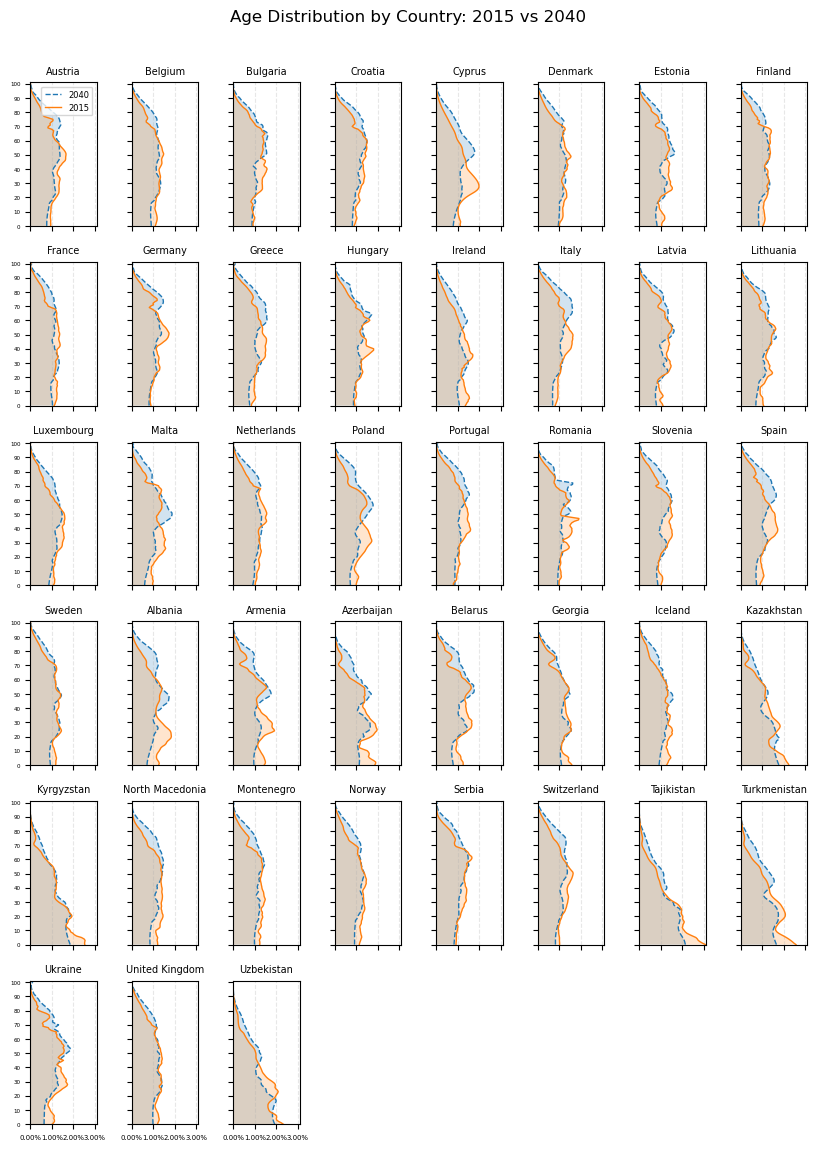

In [17]:

# Kopiera data
df_2020 = to_plot_2020.copy()
df_2015 = to_plot_2015.copy()
df_2040 = to_plot_2040.copy()

# Säkerställ samma ordning på länder
countries = df_2015["Country"].tolist()
n_plots = len(countries)

# Grid
n_cols = 8
n_rows = math.ceil(n_plots / n_cols)

# Figur
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(8.27, 11.69),
    sharex=True,
    sharey=True
)

axes = np.array(axes).reshape(-1)

# Gemensam x-skala över båda dataset
max_val = max(
    df_2015[age_cols].max().max(),
    df_2040[age_cols].max().max()
)

y_pos = np.arange(len(age_cols))

for i, country in enumerate(countries):
    ax = axes[i]

    row_2015 = df_2015.loc[df_2015["Country"] == country, age_cols].iloc[0]
    row_2040 = df_2040.loc[df_2040["Country"] == country, age_cols].iloc[0]

    values_2015 = row_2015.values.astype(float)
    values_2040 = row_2040.values.astype(float)

    # 2040
    ax.plot(values_2040, y_pos, linewidth=1, linestyle="--", label="2040")
    ax.fill_betweenx(y_pos, 0, values_2040, alpha=0.20)

    # Base
    ax.plot(values_2015, y_pos, linewidth=1, label="2015")
    ax.fill_betweenx(y_pos, 0, values_2015, alpha=0.20)

    ax.set_title(country, fontsize=7)

    tick_idx = list(range(0, len(age_cols), 10))
    ax.set_yticks(tick_idx)
    ax.set_yticklabels([age_cols[j] for j in tick_idx], fontsize=4)

    # Visa x-axeln som procent
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.01))  # 1%-steg
    
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, 101)
    ax.tick_params(axis="x", labelsize=5)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

# Ta bort tomma subplotar
for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

# Lägg legend bara i första subploten
axes[0].legend(fontsize=6, loc="upper right")

fig.suptitle("Age Distribution by Country: 2015 vs 2040", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("befolkningspyramider.png", bbox_inches="tight")
plt.show()